In [ ]:
#@title Preparação de Dependências

%pip install scikit-learn matplotlib seaborn -q

import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import export_graphviz
import graphviz


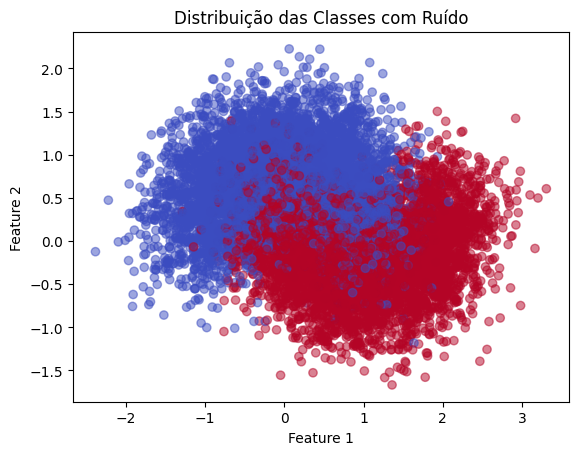

In [ ]:
#@title Seção 001: Preparação de Dados

X, y = make_moons(n_samples=10000, noise=0.4, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.5)
plt.title("Distribuição das Classes com Ruído")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


Taxa de Erro de Bayes Estimada: 0.1260
Acurácia Máxima Teórica: 0.8740



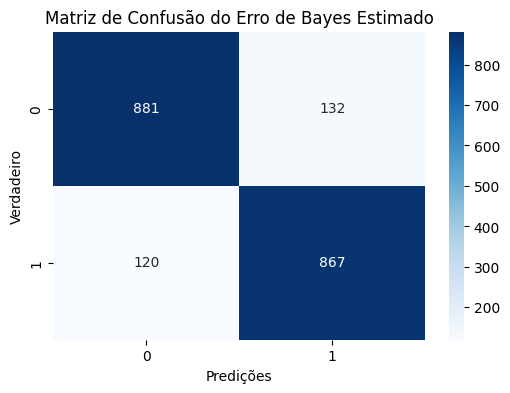

In [ ]:
#@title Estimando o Erro Teórico

gmm_0 = GaussianMixture(n_components=2, random_state=42).fit(X_train[y_train == 0])
gmm_1 = GaussianMixture(n_components=2, random_state=42).fit(X_train[y_train == 1])

def pdf_gmm(x, gmm):
    return np.exp(gmm.score_samples(x))

prob_0 = pdf_gmm(X_test, gmm_0) * (np.sum(y_train == 0) / len(y_train))
prob_1 = pdf_gmm(X_test, gmm_1) * (np.sum(y_train == 1) / len(y_train))
posterior = prob_1 / (prob_0 + prob_1)

y_pred_bayes = (posterior > 0.5).astype(int)

bayes_error = np.mean(y_pred_bayes != y_test)
print(f"\nTaxa de Erro de Bayes Estimada: {bayes_error:.4f}")
print(f"Acurácia Máxima Teórica: {1 - bayes_error:.4f}\n")

cm_bayes = confusion_matrix(y_test, y_pred_bayes)
plt.figure(figsize=(6,4))
sns.heatmap(cm_bayes, annot=True, cmap='Blues', fmt='g')
plt.title("Matriz de Confusão do Erro de Bayes Estimado")
plt.xlabel("Predições")
plt.ylabel("Verdadeiro")
plt.show()


In [ ]:
#@title Seção 002: GridSearch

param_grid = {
    'max_depth': [None, 5, 10, 15, 20],
    'max_leaf_nodes': [None, 10, 20, 50, 100]
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='accuracy',
    cv=None,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Melhores parâmetros encontrados:", best_params)


Melhores parâmetros encontrados: {'max_depth': None, 'max_leaf_nodes': 20}


In [ ]:
#@title Seção 003: Treinamento do Modelo

best_dt = DecisionTreeClassifier(**best_params, random_state=42)
best_dt.fit(X_train, y_train)


DecisionTreeClassifier(max_leaf_nodes=20, random_state=42)


Acurácia no conjunto de teste: 0.87

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1013
           1       0.88      0.86      0.87       987

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



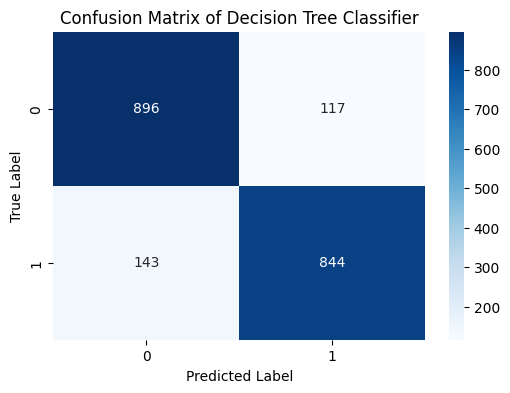

In [ ]:
#@title Resultados - Métricas

y_pred = best_dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nAcurácia no conjunto de teste:", accuracy)
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix of Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


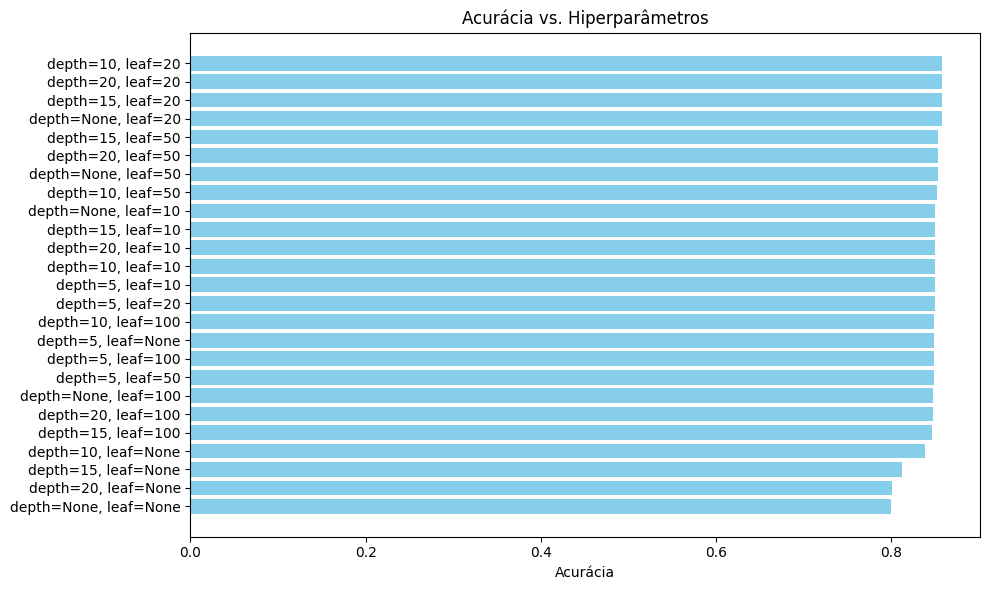

In [ ]:
#@title Resultados - Acurácia vs. Hiperparâmetros

results = grid_search.cv_results_
mean_test_scores = results['mean_test_score']
params = results['params']

params_str = [f"depth={p['max_depth']}, leaf={p['max_leaf_nodes']}" for p in params]

sorted_indices = np.argsort(mean_test_scores)
sorted_scores = mean_test_scores[sorted_indices]
sorted_params_str = np.array(params_str)[sorted_indices]

plt.figure(figsize=(10,6))
plt.barh(sorted_params_str, sorted_scores, color='skyblue')
plt.xlabel("Acurácia")
plt.title("Acurácia vs. Hiperparâmetros")
plt.tight_layout()
plt.show()


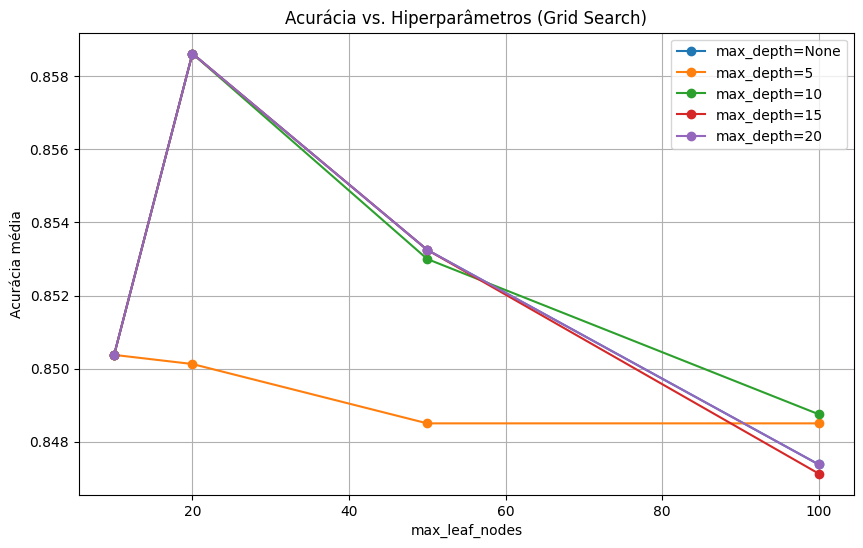

In [ ]:
#@title Resultados - Acurácia vs Hiperparâmetros

results = grid_search.cv_results_
params = results['params']
mean_test_scores = results['mean_test_score']

depth_vals = set(p['max_depth'] for p in params)
leaf_vals = set(p['max_leaf_nodes'] for p in params)

def sort_with_none(values):
    values = list(values)
    if None in values:
        values.remove(None)
        values = sorted(values)
        values = [None] + values
    else:
        values = sorted(values)
    return values

depths = sort_with_none(depth_vals)
leaf_nodes = sort_with_none(leaf_vals)

score_matrix = np.zeros((len(depths), len(leaf_nodes)))
score_matrix[:] = np.nan

for i, d in enumerate(depths):
    for j, l in enumerate(leaf_nodes):
        idx = [k for k, p in enumerate(params) if p['max_depth'] == d and p['max_leaf_nodes'] == l]
        if idx:
            score_matrix[i, j] = mean_test_scores[idx[0]]

plt.figure(figsize=(10,6))
for i, d in enumerate(depths):
    label = f"max_depth={d}" if d is not None else "max_depth=None"
    plt.plot(leaf_nodes, score_matrix[i, :], marker='o', label=label)

plt.xlabel("max_leaf_nodes")
plt.ylabel("Acurácia média")
plt.title("Acurácia vs. Hiperparâmetros (Grid Search)")
plt.legend()
plt.grid(True)
plt.show()


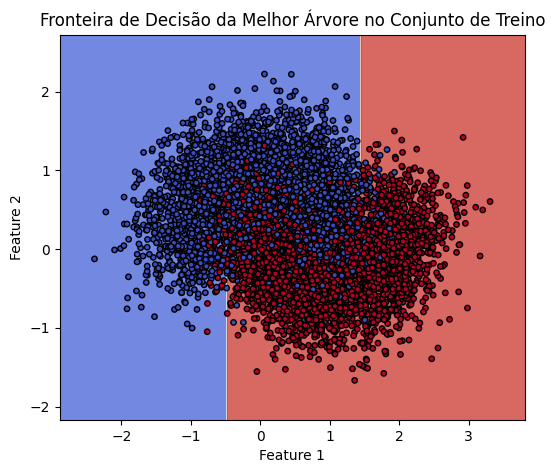

In [ ]:
#@title Resultados - Fronteira de Decisão

x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = best_dt.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolor='k', s=15, cmap=plt.cm.coolwarm)
plt.title("Fronteira de Decisão da Melhor Árvore no Conjunto de Treino")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


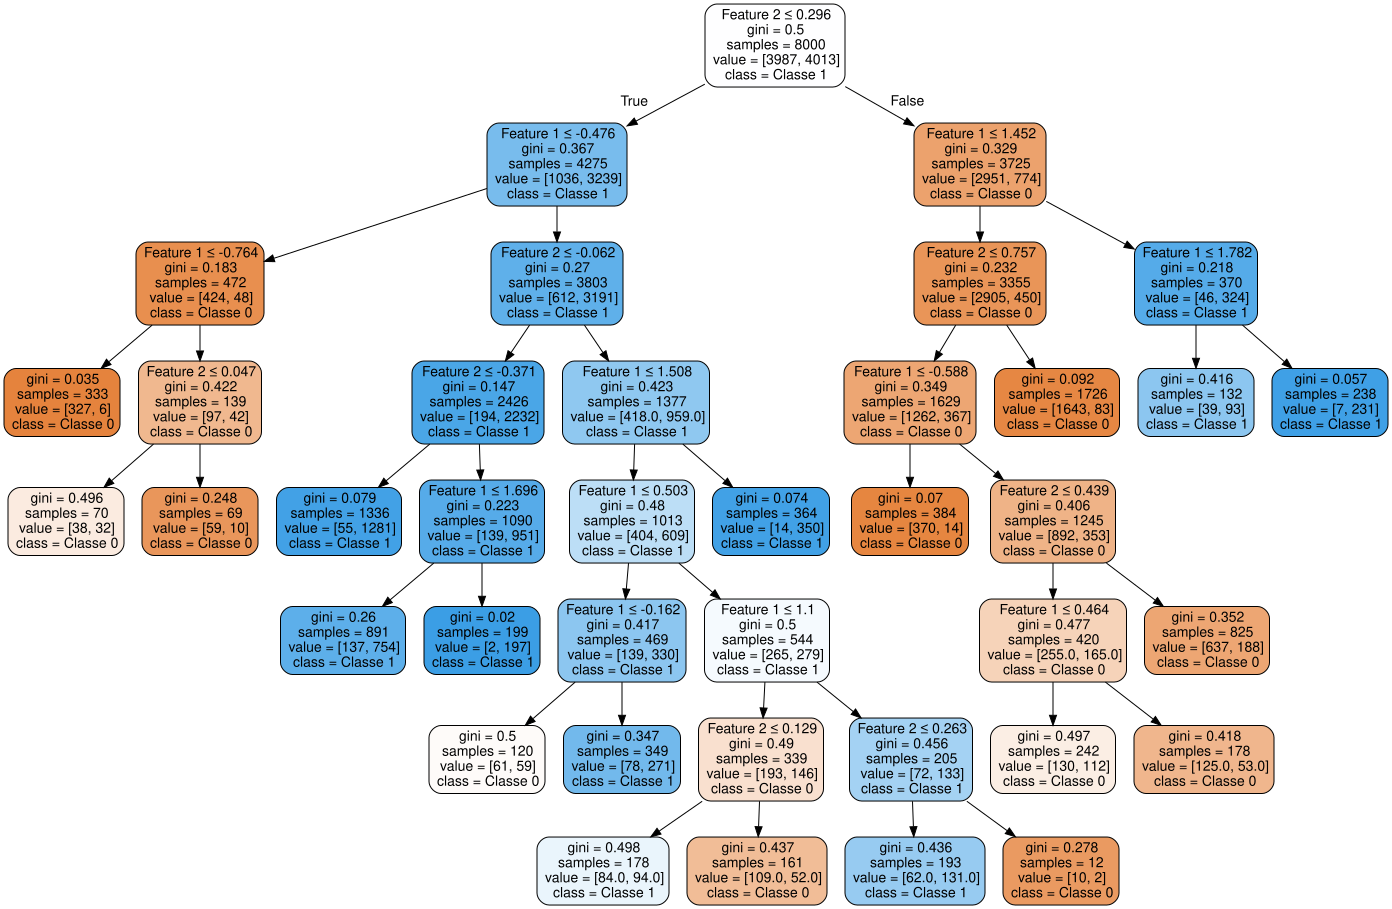

In [ ]:
dot_data = export_graphviz(
    best_dt,
    out_file=None,
    feature_names=['Feature 1', 'Feature 2'],
    class_names=['Classe 0', 'Classe 1'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("arvore_decisao_final")
graph
